In [50]:
import numpy as np

In [192]:
class Node:
    def __init__(self, inputs, func):
        self.inputs = inputs
        self.func = func

class FlowNode(Node):
    def __init__(self, inputs, func, cmap):
        super().__init__(inputs, func)
        self.cmap = cmap

class EntryNode(Node):
    def __init__(self, inputs, func, dest_comps):
        super().__init__(inputs, func)
        self.dest_comps = dest_comps

class ExitNode(Node):
    def __init__(self, inputs, func, source_comps):
        super().__init__(inputs, func)
        self.source_comps = source_comps

In [52]:
import itertools

In [53]:
list(itertools.product(["S","I","R"],["young","old"]))

[('S', 'young'),
 ('S', 'old'),
 ('I', 'young'),
 ('I', 'old'),
 ('R', 'young'),
 ('R', 'old')]

In [295]:
N_COMPS = 7
strats = ["pop", "state", "age", "class"]
hcomps = list(itertools.product(["human"],["S","I","R"],["young","old"]))

In [297]:
comps = [("wolf",None,None,"A"),("wolf",None,None,"B")] + hcomps
N_COMPS = len(comps)
comps

[('wolf', None, None, 'A'),
 ('wolf', None, None, 'B'),
 ('human', 'S', 'young'),
 ('human', 'S', 'old'),
 ('human', 'I', 'young'),
 ('human', 'I', 'old'),
 ('human', 'R', 'young'),
 ('human', 'R', 'old')]

In [878]:
class CompGroup:
    def __init__(self, comps, indices, parent=None):
        self.comps = comps
        self.indices = indices
        self.parent = parent

    def query(self, q):
        if len(q) == 2 and isinstance(q[0], str):
            strat, values = q
            strat_idx = strats.index(strat)
            qres = []
            if isinstance(values, str):
                values = [values]
            for i, c in enumerate(self.comps):
                if strat_idx in range(len(c)):
                    if c[strat_idx] in values:
                        qres.append(i)
            indices = np.array(qres)
            return CompGroup(self.comps[indices], indices, self)
        else:
            return self._multiquery(q)
    
    def _multiquery(self, queries):
        qcur = None
        for q in queries:
            qres = self.query(q)
            if qcur is None:
                qcur = set(qres.indices)
            else:
                qcur = qcur.intersection(set(qres.indices))
                                        
        indices = np.array(sorted(qcur))
        return CompGroup(self.comps[indices], indices, self)
    
    def __repr__(self):
        return "CompGroup " + repr(self.comps)

In [879]:
carr = np.array(comps,dtype=object)

In [880]:
base_cg = CompGroup(carr, np.arange(len(carr)))
#.multiquery([("age","young")])
base_cg.query([("pop", "human"),("age","young")])

CompGroup array([('human', 'S', 'young'), ('human', 'I', 'young'),
       ('human', 'R', 'young')], dtype=object)

In [881]:
base_cg.query((("age","young"),("state","I")))

CompGroup array([('human', 'I', 'young')], dtype=object)

In [882]:
base_cg.query(("age","young")).query(("state","I"))

CompGroup array([('human', 'I', 'young')], dtype=object)

In [ ]:
def query(strat, values):
    strat_idx = strats.index(strat)
    qres = []
    if isinstance(values, str):
        values = [values]
    for i, c in enumerate(comps):
        if strat_idx in range(len(c)):
            if c[strat_idx] in values:
                qres.append(i)
    return np.array(qres)

In [187]:
np.array(sorted(set(query("age","young")).intersection(set(query("state","I")))))

array([3])

In [188]:
def multiquery(queries):
    qcur = None
    for q in queries:
        qres = query(*q)
        if qcur is None:
            qcur = set(qres)
        else:
            qcur = qcur.intersection(set(qres))
                                     
    return np.array(sorted(qcur))

In [304]:
multiquery([("pop","wolf"),("class","A")])

array([0])

In [190]:
infection_cats = [
    ("age","young"),
    ("age","old")
]

In [890]:
all_pred_cats

[(('age', 'young'), ('state', 'I')),
 (('age', 'young'), ('state', ('S', 'R'))),
 (('age', 'old'), ('state', 'I')),
 (('age', 'old'), ('state', ('S', 'R')))]

In [ ]:
# Recovery: TransitionNode(I->R, rec_rate<age_cats>, proportional)
# Predation: ExitNode(humans, final_predation<all_pred_cats>, absolute, split_by_pop_ratio)

In [846]:
[base_cg.query(c) for c in infection_cats]

[CompGroup array([('human', 'S', 'young'), ('human', 'I', 'young'),
        ('human', 'R', 'young')], dtype=object),
 CompGroup array([('human', 'S', 'old'), ('human', 'I', 'old'),
        ('human', 'R', 'old')], dtype=object)]

In [ ]:
cat_indices = [base_cg.query(c).indices for c in infection_cats]

def category_idx_reduction(cat_indices: list[np.ndarray], src: jax.Array):
    if len(set([len(c) for c in cat_indices])) == 1:
        return src[np.array(cat_indices)].sum(axis=1)
    else:
        return jnp.array([src[c].sum() for c in cat_indices])


In [ ]:
# X*Y*alpha
# By default; scalar
# X[stratA_mod] * Y * alpha
# : [stratA]

In [ ]:
def get_cat_foi(mm=None):
    def foi(comp_vals):
        i_cat_idx = np.array([multiquery([c,("state","I")]) for c in infection_cats])
        pop_cat_idx = np.array([query(*c) for c in infection_cats])

        I = comp_vals[i_cat_idx]
        pops = comp_vals[pop_cat_idx]
        return I.sum(axis=1)/(pops.sum(axis=1))
    
    return foi

def predation(comp_vals, prate):
    # LtVt predation rate; alphaXY
    wolves = comp_vals[query("pop", "wolf")].sum()
    return wolves * prate

def predation_agemod(comp_vals, prate):
    # LtVt predation rate; alphaXY
    wolves = comp_vals[query("pop", "wolf")].sum()
    return wolves * prate
    
def wolf_births(comp_vals, brate):
    # LtVt birth flow; betaXY
    humans = comp_vals[query("pop", "human")].sum()
    return humans * brate



In [262]:
mm = np.array((
    [1.0,0.2],
    [0.0,1.0]
))

np.array((2.0,3.0)) @ mm, mm @ np.array((2.0,3.0))

(array([2. , 3.4]), array([2.6, 3. ]))

In [ ]:
# ODEs

# Could be anything at all
# _fundamental_ types shouldn't be proportional
# add_transition_flow assumes proportional to source
# LkVt flows are proportional to source and something else
# 

In [ ]:
query("pop","human")

# Might have huge number of categories
# Predation age;
# The final matrix requires the same number of adds
# But maybe not the same number of instructions?
# adjust(predation, {'age': 'child'}, mul(1.1))
# does the matrix even work for transforms?
# adjust(predation, limit(total_predation, wolves*max_pred_rate))
# total_predation needs to be calculated first

# total_predation = wolves * [human_pred_cats] # <pred_cats>
# 

array([1, 2, 3, 4, 5, 6])

In [280]:
from jax import numpy as jnp

In [ ]:
foi = get_cat_foi()

mm = np.array((
    [1.0,0.1],
    [0.0,1.0]
))

input_dict = {
    "comp_vals": np.array([100.0,10.0,10.0,1.0,1.0,0.0,0.0]),
    "predation_rate": 0.01,
    "wolf_birth_rate": 0.1
}

graph_dict = {
    "infection": FlowNode(["comp_vals"], lambda comp_vals: mm @ foi(comp_vals),
                          (
                            np.concat([multiquery([c,("state","S")]) for c in infection_cats]),
                            np.concat([multiquery([c,("state","I")]) for c in infection_cats]),
                          )),
    "recovery": FlowNode([], lambda: 0.2, [query("state","I"),query("state","R")]),
    "predation": ExitNode(["comp_vals","predation_rate"], predation, query("pop", "human")),
    "wolf_deaths": ExitNode([], lambda: 0.1, query("pop", "wolf")),
    "wolf_births": EntryNode(["comp_vals", "wolf_birth_rate"], wolf_births, query("pop", "wolf")),
    
}

# recovery; adjust(multiply(state_I.meta["recovery_adjust"]))

In [ ]:
# For proportional flows with no further Transform modifications
# We can assemble a matrix producing a CompartmentDelta
# We can assemble multiple matrices, or multiple direct additive deltas
# This should be invisible to the rest of the process
# For non-proportional flows we produce a CompartmentDelta directly
# For Transformed flows we consume a GraphValue and produce a GraphValue
# GraphOutputs -> 
# Final return to the integrator is a CompartmentDelta


# predation 
# plimit((WolfA * prateA)[.] * (humans*pmods[age])[age]) + plimit((WolfB * prateB) * (humans*pmods[age])[age]))

# predation = wolf * human * prate
# segment results in 2 separately transformable flows; transforms apply to each of these independantly
# predation.segment([wolf_class]).transform(plimit)
# predation = wolf[wolf_class] * human * prate[wolf_class]
# plimit(predation[wolf_class]): max_pred

In [286]:
from jax import numpy as jnp

In [862]:
# human predation categories
h_pred_cats = [
    ("age", "young"),
    ("age", "old")
]

w_cats = [
    ("class", "A"),
    ("class", "B")
]

h_disease_pred_cats = [("state", s) for s in ["I",("S","R")]]

In [865]:
def cat_product(a, b):
    return list(itertools.product(a,b))

In [883]:
all_pred_cats

[(('age', 'young'), ('state', 'I')),
 (('age', 'young'), ('state', ('S', 'R'))),
 (('age', 'old'), ('state', 'I')),
 (('age', 'old'), ('state', ('S', 'R')))]

In [ ]:
all_pred_cats = cat_product(h_pred_cats, h_disease_pred_cats)
all_pred_cats

category_idx_reduction([base_cg.query(c).indices for c in all_pred_cats],comp_vals)

class CategoryGroup:
    def __init__(self, categories):
        self.categories = categories

    def get_subindex(self, sub_cats):
        

Array([ 1., 15.,  2., 16.], dtype=float64)

In [309]:
comps

[('wolf', None, None, 'A'),
 ('wolf', None, None, 'B'),
 ('human', 'S', 'young'),
 ('human', 'S', 'old'),
 ('human', 'I', 'young'),
 ('human', 'I', 'old'),
 ('human', 'R', 'young'),
 ('human', 'R', 'old')]

In [ ]:
comp_vals = np.array(
    [
        10.0,
        20.0,
        1000.0,
        100.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)

In [ ]:
base_cg.query([("pop", "human"),("state",["S","R"])])

array([2, 3, 6, 7])

In [311]:
from jax import jit

In [782]:
class LA:
    def __init__(self, data, axes):
        self.data = data
        self.axes = axes

        self._ax_to_idx = {k:i for i,k in enumerate(axes)}
        self._idx_to_ax = {v:k for k,v in self._ax_to_idx.items()}

    def transpose(self, axes):
        transposed = self.data.transpose([self._ax_to_idx[a] for a in axes])
        return LA(transposed, axes)
    
    def expand(self, ax, index=-1):
        expanded = jnp.expand_dims(self.data, index)
        if index == -1:
            new_axes = self.axes + [ax]
        else:
            new_axes = []
            for a, i in enumerate(self.axes):
                if i == index:
                    new_axes.append(ax)
                new_axes.append(a)
        return LA(expanded, new_axes)
    
    def reconcile(self, other):
        s_set = set(self.axes)
        o_set = set(other.axes)
        s_extras = s_set.difference(o_set)
        o_extras = o_set.difference(s_set)
        other_expanded = other
        self_expanded = self
        for eax in list(s_extras):
            other_expanded = other_expanded.expand(eax)
        for eax in list(o_extras):
            self_expanded = self_expanded.expand(eax)
        return self_expanded, other_expanded.transpose(self_expanded.axes)
    
    def to_axis(self, ax):
        if ax not in self.axes:
            raise KeyError("Axis not found", ax)
        return [a for a in self.axes if a!=ax]
    
    def __mul__(self, other):
        return self._lop(other, jnp.multiply)
        if isinstance(other, float):
            return LA(self.data*other, self.axes)
        srec, orec = self.reconcile(other)
        return LA(srec.data*orec.data, srec.axes)
    
    def __rmul__(self, other):
        return self._rop(other, jnp.multiply)
    
    def __truediv__(self, other):
        srec, orec = self.reconcile(other)
        return LA(srec.data/orec.data, srec.axes)
    
    def __rtruediv__(self, other):
        return self._rop(other, jnp.true_divide)

    def _lop(self, other, op):
        if isinstance(other, float):
            return LA(op(self.data,other), self.axes)
        srec, orec = self.reconcile(other)
        return LA(op(srec.data, orec.data), srec.axes)

    def _rop(self, other, op):
        if isinstance(other, float):
            return LA(op(other, self.data), self.axes)
        else:
            raise TypeError("Unsupported type", other)
    
    def __add__(self, other):
        srec, orec = self.reconcile(other)
        return LA(srec.data+orec.data, srec.axes)
    
    def __sub__(self, other):
        srec, orec = self.reconcile(other)
        return LA(srec.data-orec.data, srec.axes)
    
    def sum(self, axis=None):
        return self._liftreduction("sum", axis)

    def _reduce_axes(self, axis=None):
        if axis is None:
            lifted_ax = None
            reduced_axes = self.axes
        elif isinstance(axis,str):
            lifted_ax = self._ax_to_idx[axis]
            reduced_axes = [a for a in self.axes if a!=axis]
        else:
            lifted_ax = [self._ax_to_idx[a] for a in axis ]
            reduced_axes = [a for a in self.axes if a not in axis]
        return lifted_ax, reduced_axes

    def _liftreduction(self, op, axis=None):
        lifted_ax, reduced_axes = self._reduce_axes(axis)
        return LA(getattr(self.data,op)(axis=lifted_ax), reduced_axes)
    
    def __repr__(self):
        data_repr = repr(self.data)
        info_repr = f"LA {self.axes} {self.data.shape}\n"
        return info_repr+data_repr


In [783]:
x = LA(jnp.linspace(0.0,1.0,5*7).reshape((5,7)), ["a","b"])
y = LA(jnp.linspace(0.0,1.0,7*11).reshape((7,11)), ["b","c"])

xr, yr = x.reconcile(y)

xr.axes, xr.data.shape, yr.axes, yr.data.shape

(xr.sum(axis="b")*yr.sum(axis="b"))

@jit
def thing(x,y):
    x_ = LA(x, ["a","b"])
    y_ = LA(y, ["b","c"])

    zr = 1.1 / (x_.sum(axis="b")*y_.sum(axis="b"))
    #assert(zr.axes == ["a","b","c"])
    print(zr.axes)
    
    return zr.data


In [784]:
@jit
def mul_by_ax(x: jax.Array,y: jax.Array):
    xa = LA(x, ["a","b"])
    ya = LA(y, ["a", "c", "b"])

    assert(x.shape[0] == y.shape[0])

    return ya.transpose(["a","b","c"]).data * xa.expand("c").data

    

In [785]:
import jax

from typing import Annotated

class GraphNode:
    def __init__(self, inputs, func, meta=None):
        self.inputs = inputs
        self.func = func
        self.meta = meta or {}

g = GraphNode([0,1],jnp.multiply)
g

In [857]:
strats

['pop', 'state', 'age', 'class']

In [ ]:
# predation is modified by;
# wolfxage
# state([inf,other])

In [ ]:
#pmax = 1.2

# pmax : maximum predation per-wolf



#prate = g("") # meta = [wolf_class]x[h_pred_cat]

#prate = 

#pred_per_wolf = human * prate[wolf_class]




def pred_per_wolf(humans, prate, pmax) -> LA:
    humans_ = LA(humans, ["h_age_cat"])
    prate_ = LA(prate, ["wolf_class","h_age_cat"])

    # WolfA - more voracious in total, eats more adults
    # WolfB - less voracious but eats more children

    # How to adjust 'inside'
    # h_pred_cats is age; but what if we want to adjust by infection status?
    # e.g I are more susceptible to predation
    # ... I are more susceptible but the total WolfHuman contact remains the same
    # h_eff = (hpops * i_adjust).renormalise 

    # and still have final wolf caps?

    # h_pred_cat = <age> * <state[I,other]>
    # what about partial or nested stratifications
    # h_pred_cat = <age> * <job_risk> # children don't have jobs. just fill with zeros?

    pred_per_wolf = prate_ * humans_ # wolf_class x h_age_cat
    # ->    
    
    ppw_wclass = pred_per_wolf.sum(pred_per_wolf.to_axis("wolf_class"))
    pred_scale = jnp.where(ppw_wclass.data>pmax, pmax/ppw_wclass.data, 1.0)

    pred_per_wolf_final = pred_per_wolf * LA(pred_scale, ["wolf_class"])

    return pred_per_wolf_final

ppwj = jit(lambda humans, prate, pmax: pred_per_wolf(humans, prate, pmax).data)


# ExitNode: humans, predation
# ExitNode: humans, predation<h_cats>

In [816]:
comp_vals = jnp.array([1.,2.,10,10,1,2,5,6])
adj_idx = np.array([3,5])
adj_vals = np.array([1.2,1.2])
comp_vals.at[adj_idx].mul(adj_vals)/comp_vals

Array([1. , 1. , 1. , 1.2, 1. , 1.2, 1. , 1. ], dtype=float64)

In [794]:
multiquery([h_pred_cats[0],h_pred_cats[1]])

array([], dtype=float64)

In [787]:
multiquery([h_pred_cats[0],("state","I")]),multiquery([h_pred_cats[0],("state",["S","R"])]),

(array([4]), array([2, 6]))

In [790]:
z = x*y
z.axes

z.sum(axis=[a for a in z.axes if a!= "c"])
z.sum(z.to_axis("c"))

LA ['c'] (11,)
Array([ 8.19465944,  8.4249226 ,  8.65518576,  8.88544892,  9.11571207,
        9.34597523,  9.57623839,  9.80650155, 10.03676471, 10.26702786,
       10.49729102], dtype=float64)

In [ ]:
prate = jnp.array([
    [0.5, 2.0],
    [1.3, 0.2]
]) * 0.5

out = []

comp_vals = np.array([1.,2.,10,10,1,2,5,6])

hcat_indices = [query(*cat) for cat in h_pred_cats]

humans_by_cat = jnp.array([comp_vals[h].sum() for h in hcat_indices])

#humans_uncat = jnp.array[[]]

pmax = jnp.array([0.4,0.6])

wolf_pop = LA(jnp.array((4.0,5.0)), ["wolf_class"])

TS = 0.1

for i in range(400):
    humans_by_cat = jnp.array([comp_vals[h].sum() for h in hcat_indices])
    pred_per_hcat = (pred_per_wolf(humans_by_cat, prate, pmax) * wolf_pop).sum(axis="wolf_class")
    final_preds = [comp_vals[h] / humans_by_cat[i] * pred_per_hcat.data[i] for i, h in enumerate(hcat_indices)]
    for preds,hidx in zip(final_preds, hcat_indices):
        comp_vals[hidx] -= preds * TS
    comp_vals[comp_vals < 0.0] = 0.0
    out.append(comp_vals.copy())



[16. 18.]
LA ['h_pred_cat'] (2,)
Array([2.84828614, 1.75171386], dtype=float64)
[15.71517139 17.82482861]
LA ['h_pred_cat'] (2,)
Array([2.84324717, 1.75675283], dtype=float64)
[15.43084667 17.64915333]
LA ['h_pred_cat'] (2,)
Array([2.83809508, 1.76190492], dtype=float64)
[15.14703716 17.47296284]
LA ['h_pred_cat'] (2,)
Array([2.83282543, 1.76717457], dtype=float64)
[14.86375462 17.29624538]
LA ['h_pred_cat'] (2,)
Array([2.82743359, 1.77256641], dtype=float64)
[14.58101126 17.11898874]
LA ['h_pred_cat'] (2,)
Array([2.82191463, 1.77808537], dtype=float64)
[14.2988198 16.9411802]
LA ['h_pred_cat'] (2,)
Array([2.81626333, 1.78373667], dtype=float64)
[14.01719346 16.76280654]
LA ['h_pred_cat'] (2,)
Array([2.8104742, 1.7895258], dtype=float64)
[13.73614604 16.58385396]
LA ['h_pred_cat'] (2,)
Array([2.80454139, 1.79545861], dtype=float64)
[13.4556919 16.4043081]
LA ['h_pred_cat'] (2,)
Array([2.79845872, 1.80154128], dtype=float64)
[13.17584603 16.22415397]
LA ['h_pred_cat'] (2,)
Array([2.7922

<Axes: >

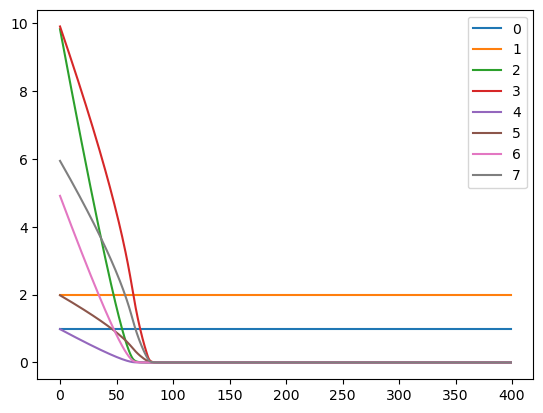

In [771]:
pd.DataFrame(out).plot()

In [720]:
hcat_indices

[array([2, 4, 6]), array([3, 5, 7])]

In [ ]:
pred_per_hcat.

LA ['h_pred_cat'] (2,)
Array([5.48353396, 5.51646604], dtype=float64)

In [708]:
hcat_indices = [query(*cat) for cat in h_pred_cats]

hcat_indices

[array([2, 4, 6]), array([3, 5, 7])]

In [709]:
comp_vals = jnp.array([10.,20.,10,10,1,2,80,82])

In [711]:
comp_vals[hcat_indices[0]].sum()

Array(91., dtype=float64)

In [ ]:
g("predation", lambda x: )

In [ ]:
    def _precompute_flow_maps(self):
        """Build fast-access arrays of flow indices"""
        f_pos_map = []
        f_neg_map = []
        for i, f in self._iter_non_function_flows:
            if f.source:
                f_neg_map.append((i, f.source.idx))
            if f.dest:
                f_pos_map.append((i, f.dest.idx))

        self._pos_flow_map = np.array(f_pos_map, dtype=int)
        self._neg_flow_map = np.array(f_neg_map, dtype=int)


In [ ]:
def build_flow_map():
    f_pos_map = []
    f_neg_map = []
    for k, v in graph_dict.items():
        cur_dict[k] = val = v.func(*[cur_dict[input_key] for input_key in v.inputs])
        if isinstance(v, FlowNode):
            src_map, dst_map = v.cmap
            trans_mat[src_map, dst_map] += val
            trans_mat[src_map, src_map] -= val
        elif isinstance(v, ExitNode):
            src_map = v.source_comps
            trans_mat[src_map, src_map] -= val
        elif isinstance(v, EntryNode):
            dest_map = v.dest_comps
            trans_mat[dest_map, dest_map] += val            

    return cur_dict, trans_mat


In [264]:
query("pop","human")

array([1, 2, 3, 4, 5, 6])

In [266]:
def compute_step_data(input_dict, graph_dict):

    trans_mat = np.zeros((N_COMPS,N_COMPS))

    cur_dict = input_dict.copy()
    for k, v in graph_dict.items():
        cur_dict[k] = val = v.func(*[cur_dict[input_key] for input_key in v.inputs])
        if isinstance(v, FlowNode):
            src_map, dst_map = v.cmap
            trans_mat[src_map, dst_map] += val
            trans_mat[src_map, src_map] -= val
        elif isinstance(v, ExitNode):
            src_map = v.source_comps
            trans_mat[src_map, src_map] -= val
        elif isinstance(v, EntryNode):
            dest_map = v.dest_comps
            trans_mat[dest_map, dest_map] += val            

    return cur_dict, trans_mat


In [267]:
def step(input_dict, graph_dict):
    mapped_dict, tmat = compute_step_data(input_dict, graph_dict)
    comp_delta = mapped_dict["comp_vals"] @ tmat
    new_comp_vals = input_dict["comp_vals"] + comp_delta
    return new_comp_vals

In [268]:
compute_step_data(input_dict, graph_dict)

({'comp_vals': array([100.,  10.,  10.,   1.,   1.,   0.,   0.]),
  'predation_rate': 0.01,
  'wolf_birth_rate': 0.1,
  'infection': array([0.1       , 0.09090909]),
  'recovery': 0.2,
  'predation': array([1.]),
  'wolf_deaths': 0.1,
  'wolf_births': np.float64(2.2)},
 array([[ 2.1       ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        , -1.1       ,  0.        ,  0.1       ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        , -1.09090909,  0.        ,  0.09090909,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , -1.2       ,  0.        ,
          0.2       ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        , -1.2       ,
          0.        ,  0.2       ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         -1.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.      

In [269]:
import pandas as pd

<Axes: >

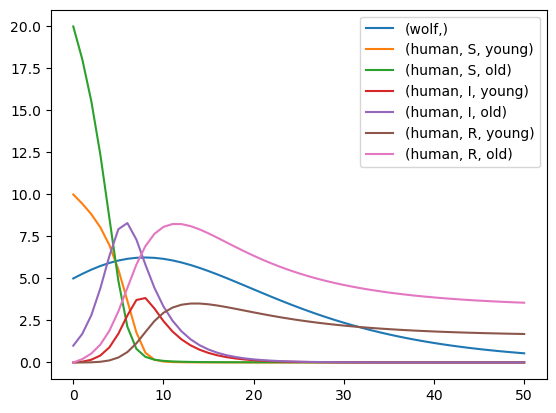

In [276]:
comp_vals = np.array([5.0,10.0,20.0,0.0,1.0,0.0,0.0])

n_steps = 50
all_vals = [comp_vals]

for i in range(n_steps):
    input_dict = {"comp_vals": comp_vals, "predation_rate": 0.01, "wolf_birth_rate": 0.005}
    comp_vals = step(input_dict, graph_dict)
    all_vals.append(comp_vals)

pd.DataFrame(np.array(all_vals),columns=comps).plot()

In [ ]:

new_comp_vals

array([9.09090909, 1.90909091, 0.        ])